a:\CERNN\Mestrado\Repositories\MassDeviation_CUDA/original_results/rho_p.txt


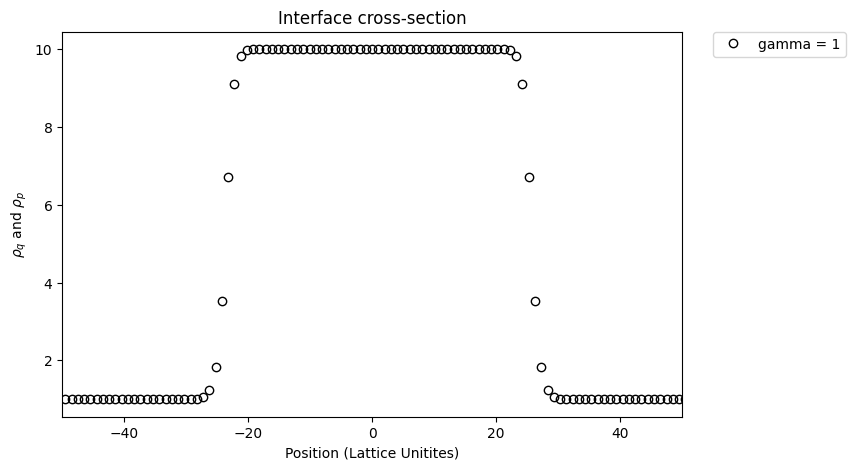

In [2]:
import os, re, itertools
from matplotlib import pyplot as plt
from math import exp, erf
from math import sqrt as sqrt
from numpy import linspace, array
import matplotlib.lines as mlines
import numpy as np
import pathlib


def get_matrix(path, H, L):
    """Gets a path and returns an existing matrix of float.
    :param path: Path of the .txt file
    :param H: number of y nodes
    :param L: number of x nodes
    :return: float matrix
    """
    matrix = []
    matrix.clear()
    try:
        file = open(path).readlines()[:]
        file = [f.strip() for f in file]
        file = " ".join(file)
        result = [float(r) for r in re.split(" * ", file)]
    except:
        print(f"This file is not in the directory: {path}")
    try:
        matrix = array(result).reshape(H, L).transpose()
    except:
        print(f"Error reshaping file: {path} in {nH}x{nL}")
    return matrix


nH = 100
nL = nH
R = int(nH / 4)

x = np.linspace(0, 1, nL)
y = np.linspace(0, 1, nH)
X, Y = np.meshgrid(x, y)

beta = 0.7
rtau = 1
rp = 1
rq = 1.0
kap = 0

dir = os.getcwd() + "/original_results/"
files = [f for f in os.listdir(dir) if os.path.isfile(os.path.join(dir, f))]

markers = itertools.cycle(("o", "^", "x", "s"))
cont = 0
cont2 = 0
leg_mark = []
plt.figure(figsize=(8, 5))
omega_q = []
omega_p = []
omega_q_num = []
omega_p_num = []

# _beta{beta:e}

for f in files:
    if "rho_p." in f:
        rho_p_num = get_matrix(dir + f, nH, nL)[:]
        print(dir + f)
        rho_q_num = get_matrix(dir + f.replace("rho_p", "rho_q"), nH, nL)[:]

        gamma = rp / rq
        hold_marker = next(markers)

        plt.plot(
            linspace(-nH / 2, nH / 2, nH) + 0.5,
            rho_p_num[:][int(nL / 2)] + rho_q_num[:][int(nL / 2)],
            color="k",
            marker=hold_marker,
            markerfacecolor="none",
            linestyle="",
            label=f"Num. p fluid rq = {rq}; γ = {gamma:.0f}",
        )
        if cont < 4:
            leg_mark.append(
                mlines.Line2D(
                    [],
                    [],
                    color="k",
                    marker=hold_marker,
                    linestyle="",
                    markerfacecolor="none",
                    label=f"gamma = {gamma:.0f}",
                )
            )
        cont += 1


plt.xlim(-nH / 2, nH / 2)
# plt.ylim(0.999,1.001)
plt.xlabel("Position (Lattice Unitites)")
plt.ylabel(r"$\rho_q$ and $\rho_p$")
plt.legend(handles=leg_mark, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title(f"Interface cross-section")
# plt.tight_layout()
plt.show()

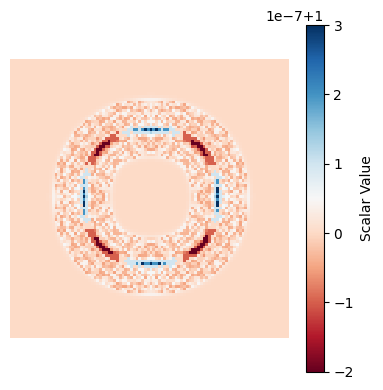

In [7]:
plt.figure(figsize=(4.5, 4.5))
plt.pcolormesh(
    X,
    Y,
    (rho_p_num).transpose() / 10 + (rho_q_num).transpose(),
    shading="auto",
    cmap="RdBu",
)  # or 'inferno', 'plasma', etc.
plt.colorbar(label="Scalar Value")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.title("Density")
plt.axis("equal")
plt.axis("off")  # hides frame, ticks, labels
# plt.grid(True)
plt.savefig("top_gamma50.png", dpi=500)
plt.show()

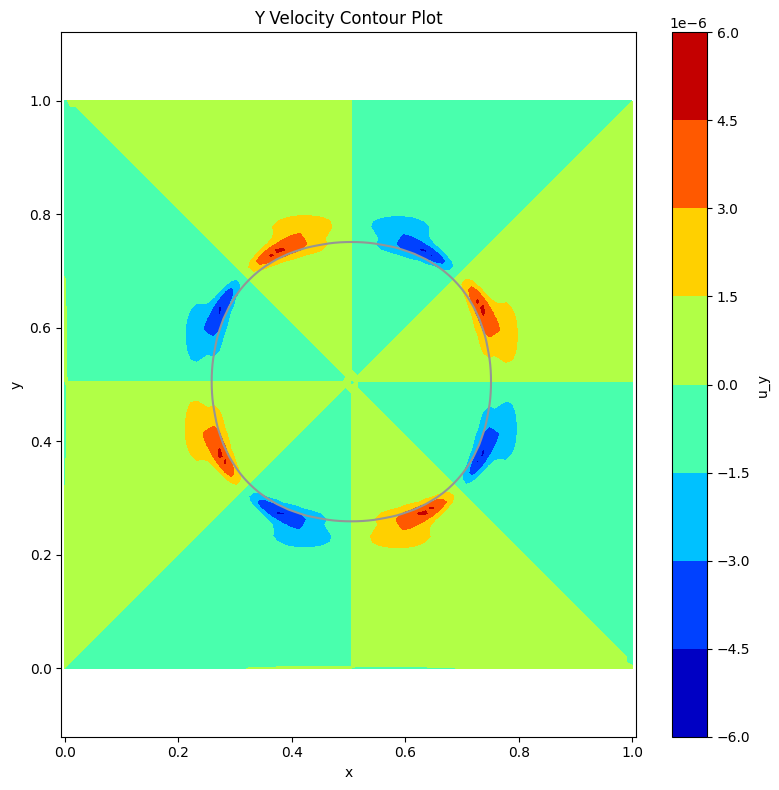

In [4]:
dir = os.getcwd() + f"/original_results/ux.txt"

dx = 1 / nL
dy = 1 / nH

ux_num = get_matrix(dir, nH, nL)[:]
uy_num = get_matrix(dir.replace("ux", "uy"), nH, nL)[:]
rho = get_matrix(dir.replace("ux", "rho_p"), nH, nL)[:]
rho = rho.transpose()

if rp == 1:
    if kap == 0:
        ux_num_rp1_k0 = ux_num
        uy_num_rp1_k0 = uy_num
        rho_p_rp1_k0 = rho_p_num
    elif kap == 1.0e-3:
        ux_num_rp1_k1e5 = ux_num
        uy_num_rp1_k1e5 = uy_num
        rho_p_rp1_k1e5 = rho_p_num
    elif kap == 1.0e-2:
        ux_num_rp1_k1e3 = ux_num
        uy_num_rp1_k1e3 = uy_num
        rho_p_rp1_k1e3 = rho_p_num
elif rp == 10:
    if kap == 0:
        ux_num_rp10_k0 = ux_num
        uy_num_rp10_k0 = uy_num
        rho_p_rp10_k0 = rho_p_num
    elif kap == 1.0e-3:
        ux_num_rp10_k1e5 = ux_num
        uy_num_rp10_k1e5 = uy_num
        rho_p_rp10_k1e5 = rho_p_num
    elif kap == 1.0e-2:
        ux_num_rp10_k1e3 = ux_num
        uy_num_rp10_k1e3 = uy_num
        rho_p_rp10_k1e3 = rho_p_num


dvdx = np.gradient(uy_num, dx, axis=0)
dudy = np.gradient(ux_num, dy, axis=1)
vorticity = dvdx - dudy

speed = np.sqrt(ux_num.transpose() ** 2 + uy_num.transpose() ** 2)  #


x = np.linspace(0, 1, vorticity.shape[1])
y = np.linspace(0, 1, vorticity.shape[0])
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8, 8))
contour = plt.contourf(X, Y, vorticity.transpose(), levels=8, cmap="jet")
# contour = plt.contourf(X, Y, speed, levels = 8, cmap='jet')
contour2 = plt.contour(X, Y, rho, levels=1, cmap="Greys")
plt.colorbar(contour, label="u_y")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Y Velocity Contour Plot")
plt.axis("equal")
plt.tight_layout()
plt.show()